# The Market Seam — Two Engines, One Grid

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

This notebook is the **hinge** between two questions the series keeps apart. Inside
**one** market, two balancing authorities co-optimise a single dispatch: congestion
is managed centrally and the only open question is how to *allocate* the rent.
Between **two** markets operating next to each other, each clears independently on
the same grid and enforces only its own constraints, so managing congestion at the
seam is itself the problem and the interchange settlement rides on top.

The construct is the **mirror image** of the two-balancing-authority story: the same
bus partition, the same two boundary wires, one allocated to each side. Run as one
market, the two sides form a coalition, co-optimise one dispatch, and work through
allocating the congestion revenue the ties collect. Run side-by-side as two markets,
the same wires become a seam, and the work is coordinating congestion that no single
engine prices.

The whole distinction reduces to one object — the set of transmission constraints
each engine treats as enforceable. Share it in one clearing, and the seam is an
accounting overlay. Split it, and the same physical bus carries **two prices**.

Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`revenue_allocation`, `seams_engine`, `wscc9_figures`.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing (the
# modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
               "wscc9_model.py", "footprints.py", "revenue_allocation.py",
               "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")

Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures, atc
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures, atc):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)
print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model. Market A holds the cheap fleet
# (bus 3 $20, bus 2 $35); Market B holds only the expensive bus-1 unit ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)
LOADS     = dict(wm.DEFAULT_LOADS)
print('loads (MW):', LOADS, ' total', sum(LOADS.values()))
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

 total

315.0

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. One market, one clearing

A single market clears one security-constrained economic dispatch over **all**
participating buses. It minimises dispatch cost subject to system energy balance,
the activated line limits, and (when it binds) the scheduled interchange:

$$\min_{g}\ \sum_i c_i\,g_i \quad\text{s.t.}\quad \sum_i g_i = \sum_n d_n\ \ [\lambda],\qquad -\bar F_m \le F_m \le \bar F_m\ \ [\mu_m]. \tag{1}$$

The nodal price is the energy price plus the shift-factor-weighted sum of the
binding-line duals (signed $\mu$):

$$\lambda_n = \lambda + \sum_m SF_{n,m}\,\mu_m. \tag{2}$$

Price separation across a binding line is **congestion rent** — what load pays over
what generation is paid:

$$R = \sum_m |\mu_m|\,|F_m| = \sum_n \lambda_n d_n - \sum_n \lambda_n g_n. \tag{3}$$

With **one** clearing over both footprints, every monitored line is priced in one
dispatch, every bus has a single price, and $R$ is a single pool. The only open
question is how to split it — the subject of the allocation notebook.

In [4]:
# -- EDIT -- one market over BOTH footprints (uncongested base) -----------
LINE_RATINGS = {}          # no internal limit binds in this baseline
SHED_PRICE   = 150.0       # $/MWh load-shed penalty (power-balance relaxation)
# -------------------------------------------------------------------------
net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
resU = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)

R = sum(abs(v) * abs(resU.flow_own[l]) for l, v in resU.line_dual.items())
print('one clearing over all buses:')
print('  dispatch (MW):', {k: round(v) for k, v in resU.dispatch.items()})
print('  energy price :', round(resU.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in resU.line_dual.items() if abs(v) > 1e-3}
print('  binding lines:', binding or 'none')
print('  congestion rent R = $%.0f' % R)
print()
print('LMP by bus ($/MWh) — one price at every bus:')
pd.Series({b: round(resU.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


one clearing over all buses:

  dispatch (MW):

{'gen_slack_0': 0, 'gen_0': 145, 'gen_1': 170}

  energy price :

...

  binding lines:

none

  congestion rent R = $0

LMP by bus ($/MWh) — one price at every bus:

,1,2,3,4,5,6,7,8,9
LMP,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0


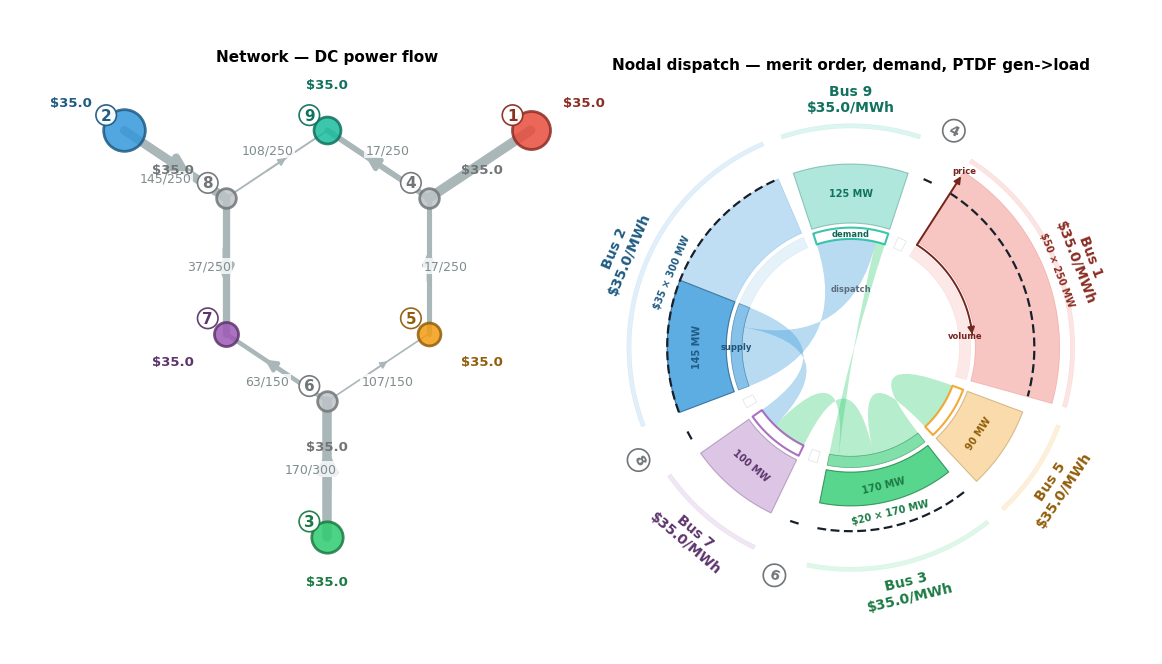

In [5]:
# The one clearing as a two-panel composite: network DC power flow (left) and the
# nodal dispatch merit order (right).
sup, dem = to_supply_demand(unified, resU)
binding_lines = {l for l, mu in resU.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=dict(BUS_COLORS), bus_lmps=resU.lmp,
    line_flows={l: resU.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(resU, dem)),
    clearing_price=resU.energy_price,
    demand_segments=shed_segments(resU, dem),
    lmp_line=True, annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,
    title_right='Nodal dispatch — merit order, demand, PTDF gen->load',
)
plt.show()

**Read it.** Uncongested, every bus clears at the same price and $R=0$: no
binding line, no price separation. This is the intra-market baseline — the cheap
fleet serves the whole system in one co-optimised dispatch. The next section clears
the *same* buses as two independent markets and the picture changes at once.

## 2. Two markets on one grid — the activated-constraint dial

Now clear the same buses as **two** independent markets. Each market dispatches only
its own resources, serves only its own loads, and enforces a flow limit only on the
constraints **allocated** to it — the lines whose endpoints both lie inside its
footprint, plus the seam line it manages:

$$\mathcal M^{M}_{\text{act}} = \{\, m : \text{both endpoints of } m \text{ in market } M \,\} \;\cup\; \{\, \text{the seam line allocated to } M \,\},\qquad M\in\{A,B\}. \tag{4}$$

A constraint outside $\mathcal M^{M}_{\text{act}}$ is still in market $M$'s network
— its flow is still computed — but its limit is relaxed, so market $M$ *sees* the
flow it causes there and does not *price* it. The two lines that span the seam form
the **intertie set**, and each is allocated to one manager — the same one-tie-each
construct as the two-balancing-authority examples (one side managing the 5–6 tie,
the other the 8–9 tie), carried across the institutional divide:

$$\mathcal I^{AB} = \{\, m_{56},\; m_{89} \,\},\qquad m_{56}\in\mathcal M^{A}_{\text{act}},\qquad m_{89}\in\mathcal M^{B}_{\text{act}}. \tag{5}$$

**Allocation is not coordination.** A manager enforces its seam line's rating against
the flow *it* computes — its own injections — while the other market's component
rides the same wire unseen, and no engine schedules the interchange across the pair.
That is the dial. Enforce **everything in one clearing** and the two footprints are
two balancing authorities inside one market: the boundary wires are ties, their rent
lands in one pool, and the open question is *allocation*. Split the clearing so each
side enforces only its share, and the identical wires become a seam: nothing prices
the superposed flow, and the open question is *coordination* — the mirror image.

In [6]:
# -- EDIT -- the two market footprints and each market's monitored set -----
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet ($20 at 3, $35 at 2); load at 7 -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the $50 unit at bus 1; loads 5, 9 -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}
MONITORED_LINES = {                # M^M_act: internal lines + the allocated seam line
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 (5-6) = A's seam line
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 (8-9) = B's seam line
}
# -------------------------------------------------------------------------
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='seam')
mkt_of     = fp.fp_of
seam_lines = fp.ties     # the intertie set I^AB

A = make_engine('Market A', MKT_DEFS['Market A'], activated=MONITORED_LINES['Market A'])
B = make_engine('Market B', MKT_DEFS['Market B'], activated=MONITORED_LINES['Market B'])

print('Market A buses:', MKT_DEFS['Market A'], '| monitors', MONITORED_LINES['Market A'])
print('Market B buses:', MKT_DEFS['Market B'], '| monitors', MONITORED_LINES['Market B'])
print()
print('intertie set I^AB -- one seam line allocated to each market (the two-BA construct):')
for l in seam_lines:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    print(f'  {l} ({b0}-{b1}): managed by {fp.monitored_by(l)[0]}')
print('A manager enforces only its OWN flow component -- no engine prices the superposition.')

Market A buses:

['2', '8', '7', '6', '3']

| monitors

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

Market B buses:

...

['line_0', 'line_1', 'line_7', 'line_8']

intertie set I^AB -- one seam line allocated to each market (the two-BA construct):

  line_2 (5-6): managed by Market A

  line_7 (8-9): managed by Market B

A manager enforces only its OWN flow component -- no engine prices the superposition.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


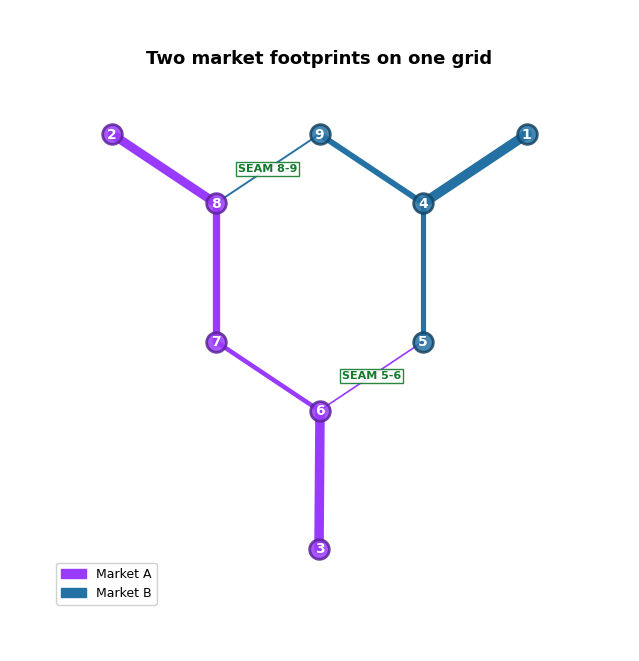

In [7]:
# Map of the two footprints and the seam lines (buses coloured by market).
mkt_bus_colors = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=mkt_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=fp.line_colors(pt),      # lines coloured by their managing market
    title='Two market footprints on one grid',
)
for l in seam_lines:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'SEAM {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

## 3. Two engines, two prices — the seam dual gap

Clear A and B independently, with no interchange scheduled. Each bus now has **two**
prices — one per engine — because the two clearings differ in three ways even on the
shared network:

$$\lambda^{A}_n = \lambda^{A} + \sum_{m\in\mathcal M^{A}_{\text{act}}} SF_{n,m}\,\mu^{A}_m,\qquad \lambda^{B}_n = \lambda^{B} + \sum_{m\in\mathcal M^{B}_{\text{act}}} SF_{n,m}\,\mu^{B}_m. \tag{6}$$

The shift factors are shared, but the marginal unit ($\lambda^{A}$ vs $\lambda^{B}$),
the set of binding constraints, and the served loads all differ between engines. The
**seam dual gap** is the difference, and it is generically non-zero at *every* bus:

$$\Delta\lambda^{AB}_n = \lambda^{B}_n - \lambda^{A}_n \ne 0. \tag{7}$$

In [8]:
rA = solve_engine_dispatch(pt, A)   # no exo: zero scheduled interchange
rB = solve_engine_dispatch(pt, B)
print(f"Market A energy price ${rA.energy_price:>4.0f}/MWh (cheap fleet)   cost ${rA.total_cost:,.0f}")
print(f"Market B energy price ${rB.energy_price:>4.0f}/MWh (the $50 unit)   cost ${rB.total_cost:,.0f}")
print()
print('Two prices at every bus, and their gap (no line binding — this is NOT congestion):')
seam_dual_gap([rA, rB], pt.buses)

Market A energy price $  20/MWh (cheap fleet)   cost $2,000

Market B energy price $  50/MWh (the $50 unit)   cost $10,750

Two prices at every bus, and their gap (no line binding — this is NOT congestion):

,λ[Market A],λ[Market B],Δλ[Market A→Market B]
bus,,,
1,20.0,50.0,30.0
2,20.0,50.0,30.0
3,20.0,50.0,30.0
4,20.0,50.0,30.0
5,20.0,50.0,30.0
6,20.0,50.0,30.0
7,20.0,50.0,30.0
8,20.0,50.0,30.0
9,20.0,50.0,30.0


**Read it.** Same buses, same shift factors — but a price from Market A's merit
order and a different price from Market B's. The gap is the merit-order difference
between two disjoint resource stacks, and it appears with **no line binding**: the
seam is two prices at one bus, not a congestion charge. Congestion enters in Section
5, on top of this.

## 4. The seam schedule and the interface

Allocating the seam lines settles who guards each wire; it does not create a
scheduler. The interchange across the seam is a decision variable of **neither**
clearing — it is set externally, by a bilateral transaction or a seam-scheduling
process, then presented to each engine as a fixed, price-taking injection:

$$F^{\text{seam}} = E\ \ (\text{external}):\quad \text{Market A sees } -E \text{ (an export it serves)},\quad \text{Market B sees } +E \text{ (an import that displaces its own supply)}. \tag{8}$$

A scheduled megawatt must be *placed* on the network before its shift factor is
defined — at the intertie bus (SP-Tie) or spread over the neighbour's generation
(GAP-Tie). Where it sits changes which monitored lines it appears to load; that
placement question is the subject of the intertie notebook. Each engine also prices
its external interface differently — a generation-weighted aggregation on one side,
a load-weighted average on the other — so the two legs of one transaction can settle
at two prices.

In [9]:
# A exports E MW to B: a withdrawal A must serve, an injection that backs down B's $50 unit.
EXPORT_BUS, IMPORT_BUS = '6', '5'      # the seam (5-6) endpoints: A side / B side
rows = []
for E in (0, 40, 80, 120):
    ra = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -float(E)}, shed_price=SHED_PRICE)
    rb = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +float(E)}, shed_price=SHED_PRICE)
    rows.append({'E (MW)': E,
                 'A price': round(ra.energy_price),
                 'B price': round(rb.energy_price),
                 'C_A+C_B ($)': round(ra.total_cost + rb.total_cost)})
print("The schedule enters each engine as a fixed injection; B backs down its $50 unit,")
print("A generates the cheap megawatt instead, and the combined production bill falls:")
pd.DataFrame(rows).set_index('E (MW)').T

The schedule enters each engine as a fixed injection; B backs down its $50 unit,

A generates the cheap megawatt instead, and the combined production bill falls:

E (MW),0,40,80,120
A price,20,20,35,35
B price,50,50,50,50
C_A+C_B ($),12750,11550,10500,9900


**Read it.** The interchange is *scheduled*, not co-optimised: each engine
takes it as data. In this single-unit fleet Market B's marginal price stays at its
one unit's cost until that unit is fully displaced, so the headline gap moves in
steps — but the combined production cost falls with every megawatt, which is the
welfare content Section 6 makes precise.

## 5. Congestion management across the seam — one mechanism, three faces

Every congestion problem at a seam is one statement: a constraint
$m \notin \mathcal M^{M}_{\text{act}}$ that market $M$'s dispatch nonetheless loads.
The series meets it in three guises — all the same mechanism:

- **dispatch interference** — the physical superposition $F_m = F^{A}_m + F^{B}_m$ overloads a line each market counted only its own half of (the seam-issues notebook);
- **phantom congestion** — where the schedule is placed gives it a shift factor onto a line the true flow does not load, so the line *appears* to bind (the intertie notebook);
- **the neighbour's contingency** — a monitored line loaded, under its worst outage, by the other market's injection, with the cheapest relief outside this market's dispatch (the contingency notebook).

Whether a *set* of schedules respects every monitored line is the
**simultaneous-feasibility test** — the shared detection tool. The netted test
credits counterflow (the financial standard); the firm test sums same-direction
loadings without crediting it (the OATT-capacity standard):

$$\Big|\textstyle\sum_r a_m(s_r,k_r)\,q_r\Big| \le \bar F_m\ \ (\text{netted}),\qquad \max\!\Big(\textstyle\sum_r [a_m q_r]_+,\ \sum_r [-a_m q_r]_+\Big) \le \bar F_m\ \ (\text{firm}). \tag{9}$$

No single agent runs this test over the union of both markets' books — which is why
the West's live conversation is about a *common* simultaneous-feasibility test.

In [10]:
# Impose the internal limit and clear both markets blind (no interchange).
netc = build_network({'line_4': 40.0})     # line_4 (6-7) is internal to Market A
ptc  = compute_ptdf(netc, slack_bus='1')
Ac = make_engine('Market A', MKT_DEFS['Market A'], activated=MONITORED_LINES['Market A'])
Bc = make_engine('Market B', MKT_DEFS['Market B'], activated=MONITORED_LINES['Market B'])
rAc = solve_engine_dispatch(ptc, Ac)
rBc = solve_engine_dispatch(ptc, Bc)

pf = physical_flows(ptc, [rAc, rBc])
print("Each market clears within its own monitored set, yet the physical wire can overload:")
print(pf[['from', 'to', 'F[Market A]', 'F[Market B]', 'F_phys', 'rating', 'loading_%', 'overload']].to_string())
ovl = pf[pf.overload]
for ln, row in ovl.iterrows():
    print(f"\n[!] {ln} ({row['from']}-{row['to']}): |F_phys|={abs(row.F_phys):.1f} > {row['rating']:.0f} MW  "
          f"— Market A sees {row['F[Market A]']:+.1f}, Market B sees {row['F[Market B]']:+.1f}, neither enforces it.")

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Each market clears within its own monitored set, yet the physical wire can overload:

       from to  F[Market A]  F[Market B]  F_phys  rating  loading_%  overload
line                                                                         
line_0    1  4          0.0        215.0   215.0   250.0       86.0     False
line_1    4  5          0.6         93.4    94.0   250.0       38.0     False
line_2    5  6          0.6          3.4     4.0   150.0        3.0     False
line_3    3  6         39.4         -0.0    39.4   300.0       13.0     False
line_4    6  7         40.0          3.4    43.4    40.0      109.0      True
line_5    7  8        -60.0          3.4   -56.6   250.0       23.0     False
line_6    8  2        -60.6          0.0   -60.6   250.0       24.0     False
line_7    8  9          0.6          3.4     4.0   250.0        2.0     False
line_8    9  4          0.6       -121.6  -121.0   250.0       48.0     False


[!] line_4 (6-7): |F_phys|=43.4 > 40 MW  — Market A sees +40.0, Market B sees +3.4, neither enforces it.

In [11]:
# The detection tool: test the two markets' gen->load use as a set of point-to-point
# schedules with the SFT. The netted test credits counterflow; the firm test does not.
awards = [atc.Award('3', '7', 100),    # Market A: cheap unit -> its load
          atc.Award('1', '9', 125),    # Market B: the $50 unit -> its loads
          atc.Award('1', '5', 90)]
feas_net,  tbl_net  = atc.simultaneous_feasibility(ptc, awards, monitored='all')
feas_firm, tbl_firm = atc.firm_feasibility(ptc, awards, monitored='all')
print(f"netted SFT feasible? {feas_net}    firm (no-counterflow) feasible? {feas_firm}")
print("\nFirm line loadings on line_4 (the shared element neither market prices):")
print(tbl_firm.loc[['line_4'], ['from', 'to', 'fwd', 'rev', 'firm', 'limit', 'overload']].to_string())

netted SFT feasible? False    firm (no-counterflow) feasible? False


Firm line loadings on line_4 (the shared element neither market prices):

       from to    fwd   rev   firm  limit  overload
line                                               
line_4    6  7  100.8  12.2  100.8   40.0      True

**Read it.** Both markets returned feasible on their own monitored sets, yet
the superposed flow can exceed a rating neither prices — the loop-flow externality at
the heart of the Western seam. The simultaneous-feasibility test over the *union* of
the two books is exactly what catches it, and the firm-vs-netted split is the
OATT-vs-financial-rights distinction made numeric. It is the same tool the ATC
notebook posts capacity with; here it is the seam's congestion-management check.

## 6. The unified counterfactual and the welfare loss

The efficiency benchmark is the joint clearing over both footprints — Section 1's one
market, now read as the *counterfactual* for two:

$$\min_{g}\ C^{A} + C^{B}\quad\text{(one balance, the union of limits, free interchange)}. \tag{10}$$

The welfare loss from clearing separately at a seam schedule $E$ is the extra
production cost, zero when $E$ equals the unified inter-market flow:

$$\mathcal W(E) = \big[C^{A\star} + C^{B\star}\big](E) - C^{\star}\ \ge 0. \tag{11}$$

Marginal welfare per scheduled megawatt is the cross-bus dual gap — welfare improves
at the rate of the seam dual gap until it closes or the intertie binds:

$$\frac{\partial\,[C^{A\star}+C^{B\star}]}{\partial E} = \lambda^{A} - \lambda^{B} = -\,\Delta\lambda^{AB}. \tag{12}$$

In [12]:
# Sweep the seam schedule on the uncongested network; W(E) -> 0 at the unified flow.
netu = build_network({}); ptu = compute_ptdf(netu, slack_bus='1')
Au = make_engine('Market A', MKT_DEFS['Market A'], activated=MONITORED_LINES['Market A'])
Bu = make_engine('Market B', MKT_DEFS['Market B'], activated=MONITORED_LINES['Market B'])
Uu = make_engine('UNIFIED', buses=ptu.buses)
Cstar = solve_engine_dispatch(ptu, Uu, shed_price=SHED_PRICE).total_cost

rows = []
for E in (0, 40, 80, 120, 160, 200, 215):
    ra = solve_engine_dispatch(ptu, Au, exo={'6': -float(E)}, shed_price=SHED_PRICE)
    rb = solve_engine_dispatch(ptu, Bu, exo={'5': +float(E)}, shed_price=SHED_PRICE)
    tot = ra.total_cost + rb.total_cost
    rows.append({'E (MW)': E, 'C_A+C_B ($)': round(tot), 'W(E) ($)': round(tot - Cstar)})
print(f"Unified benchmark  C* = ${Cstar:,.0f}   (one clearing, cheap fleet serves all 315 MW)")
pd.DataFrame(rows).set_index('E (MW)').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Unified benchmark  C* = $8,475   (one clearing, cheap fleet serves all 315 MW)

E (MW),0,40,80,120,160,200,215
C_A+C_B ($),12750,11550,10500,9900,9300,8700,8475
W(E) ($),4275,3075,2025,1425,825,225,0


**Read it.** The welfare loss falls monotonically toward zero as the seam
schedule approaches the unified inter-market flow (here, all of Market B's load
served from the cheap fleet). $\mathcal W$ is what the seam costs when the schedule
is short of that flow — and, by eq. (12), the marginal gain per megawatt is exactly
the seam dual gap of Section 3. A perfectly informed scheduler with unlimited
intertie capacity would drive it to zero and reproduce the one-market outcome; a
forecast, a binding intertie, and two interface prices are why it cannot.

## 7. Allocation vs coordination — the bridge

The dial of Section 2 sets which question you are answering.

**Enforce the union in one clearing (one market).** Congestion is co-optimised,
every bus has one price, and the pool $R$ is collected once — the boundary wires
are ties whose rent lands in the pool. Revenue adequacy holds by construction, and
the open question is *distribution* — the allocation notebook, where the two sides
build the coalition and split what the ties collect.

**Split it (two markets).** The first question is not distribution but
*coordination*: whether the two clearings are jointly feasible at all (Section 5),
and how the interchange that crosses the seam is scheduled and settled when each
seam line has a manager but the pair has no scheduler, and the interface is priced
two ways. The revenue a seam produces is the seam dual gap times the scheduled flow,
bounded by the welfare loss of Section 6 — a bilateral settlement, not a pool.

Allocating congestion revenue between authorities in one market and coordinating
congestion between adjacent markets are therefore the two settings of one dial —
the same partition, the same two wires, mirror images across the institutional
divide. The next notebook works the three coordination issues in detail.

---